# 🐳 Machine Learning for Predicting Docker Container Failures
**Name:** Pruthviraj Santosh Patil &nbsp;&nbsp;|&nbsp;&nbsp; **URN:** 23031042 &nbsp;&nbsp;|&nbsp;&nbsp; **Roll No.:** 3005 &nbsp;&nbsp;|&nbsp;&nbsp; **Class:** TY-A

**College:** Annasaheb Dange College of Engineering and Technology, Ashta

**Under Guidance of:** Prof. S. D. Khatavkar

---
## What this project does
We build a machine learning model that watches container metrics (CPU%, Memory%, Errors) over time
and **predicts if a container is about to fail** before it actually crashes.

We use an **LSTM (Long Short-Term Memory)** neural network because it can read patterns across time.

### Steps we follow:
1. Generate realistic container metrics data
2. Explore and visualise the data
3. Preprocess and prepare data for LSTM
4. Build and train the LSTM model
5. Evaluate using Accuracy, Precision, Recall and F1-Score
6. Visualise the results

---
## Step 1 — Install and Import Libraries
These are the tools we use. Run this cell first.

In [1]:
# Install if running on Google Colab
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Fix random seed so results are same every time
np.random.seed(42)
tf.random.set_seed(42)

print('✅ All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

ModuleNotFoundError: No module named 'tensorflow'

---
## Step 2 — Generate Container Metrics Dataset
We create a realistic dataset of 3000 time steps (every 5 minutes = 250 hours of data).
Each row has: CPU%, Memory%, Error Count, Network I/O — and a **Failure** label (1 = failed, 0 = healthy).

In [2]:
def generate_container_data(n_samples=3000, failure_rate=0.15):
    """
    Generates realistic container telemetry data.
    Failing containers show rising memory and CPU before crash.
    """
    np.random.seed(42)
    data = []
    failure_label = []
    
    i = 0
    while i < n_samples:
        # Decide: healthy container or failing container?
        is_failing = np.random.random() < failure_rate
        
        if is_failing:
            # Failing container: gradual increase in memory and errors over 30-60 steps
            fail_steps = np.random.randint(30, 60)
            fail_steps = min(fail_steps, n_samples - i)
            
            for t in range(fail_steps):
                progress = t / fail_steps  # 0 to 1 (getting closer to failure)
                
                cpu    = 40 + 45 * progress + np.random.normal(0, 3)
                memory = 50 + 40 * progress + np.random.normal(0, 2)
                errors = int(2  + 15 * progress + np.random.exponential(1))
                net_io = 30 + 10 * progress + np.random.normal(0, 5)
                
                cpu    = np.clip(cpu,    0, 100)
                memory = np.clip(memory, 0, 100)
                errors = max(0, errors)
                net_io = np.clip(net_io, 0, 100)
                
                # Label as failure only in the final 20% of the window
                label = 1 if progress > 0.80 else 0
                
                data.append([cpu, memory, errors, net_io])
                failure_label.append(label)
            i += fail_steps
        else:
            # Healthy container: normal, stable readings
            cpu    = np.random.uniform(20, 55) + np.random.normal(0, 3)
            memory = np.random.uniform(30, 60) + np.random.normal(0, 2)
            errors = int(np.random.exponential(0.5))
            net_io = np.random.uniform(20, 50) + np.random.normal(0, 5)
            
            cpu    = np.clip(cpu,    0, 100)
            memory = np.clip(memory, 0, 100)
            errors = max(0, errors)
            net_io = np.clip(net_io, 0, 100)
            
            data.append([cpu, memory, errors, net_io])
            failure_label.append(0)
            i += 1
    
    df = pd.DataFrame(data[:n_samples],
                      columns=['CPU_Percent', 'Memory_Percent', 'Error_Count', 'Network_IO'])
    df['Failure'] = failure_label[:n_samples]
    return df

# Generate the data
df = generate_container_data(n_samples=3000)

print('✅ Dataset generated!')
print(f'Total rows     : {len(df)}')
print(f'Healthy rows   : {(df.Failure==0).sum()} ({(df.Failure==0).mean()*100:.1f}%)')
print(f'Failure rows   : {(df.Failure==1).sum()} ({(df.Failure==1).mean()*100:.1f}%)')
print('\nFirst 5 rows:')
df.head()

✅ Dataset generated!
Total rows     : 3000
Healthy rows   : 2494 (83.1%)
Failure rows   : 506 (16.9%)

First 5 rows:


,CPU_Percent,Memory_Percent,Error_Count,Network_IO,Failure
0,55.218066,37.726619,0,23.137715,0
1,23.752003,58.158347,0,28.214936,0
2,33.191722,47.231012,0,25.247620,0
3,20.569720,44.338268,0,25.670337,0
4,40.285377,51.329309,2,33.895963,0


---
## Step 3 — Explore and Visualise the Data (EDA)
Before training any model, we look at the data visually to understand it.

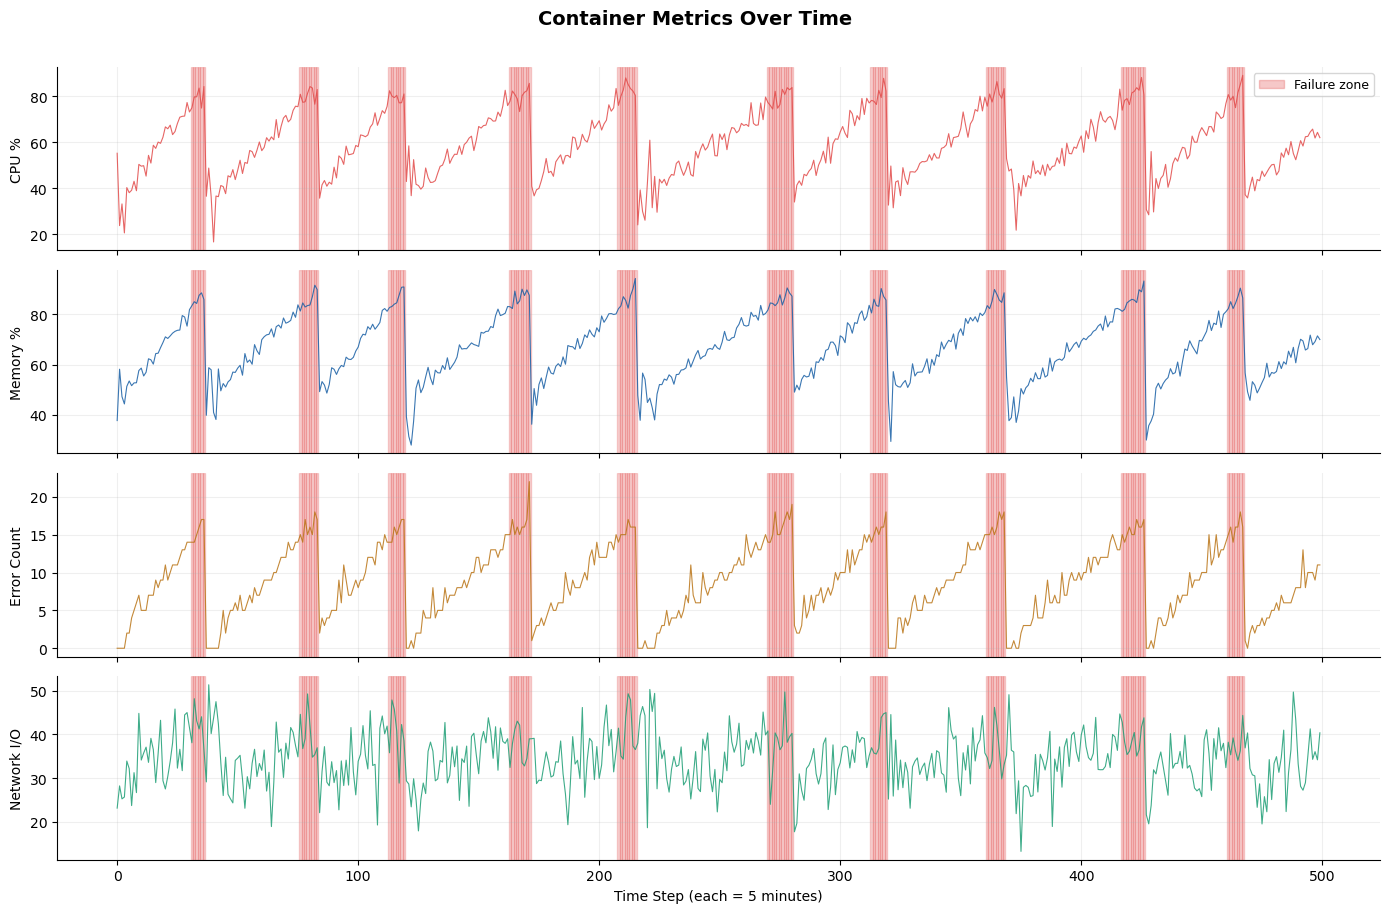


📊 Red shaded areas = where containers are failing


In [3]:
# ── Plot 1: All 4 metrics over time ──────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Container Metrics Over Time', fontsize=14, fontweight='bold', y=1.01)

cols   = ['CPU_Percent', 'Memory_Percent', 'Error_Count', 'Network_IO']
colors = ['#E24B4A', '#185FA5', '#BA7517', '#1D9E75']
labels = ['CPU %', 'Memory %', 'Error Count', 'Network I/O']

for ax, col, color, label in zip(axes, cols, colors, labels):
    ax.plot(df.index[:500], df[col][:500], color=color, lw=0.8, alpha=0.85)
    # Highlight failure zones in red
    fail_idx = df.index[:500][df['Failure'][:500] == 1]
    for fi in fail_idx:
        ax.axvspan(fi - 0.5, fi + 0.5, color='#E24B4A', alpha=0.25)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

axes[-1].set_xlabel('Time Step (each = 5 minutes)', fontsize=10)
red_patch  = mpatches.Patch(color='#E24B4A', alpha=0.3, label='Failure zone')
axes[0].legend(handles=[red_patch], loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Red shaded areas = where containers are failing')

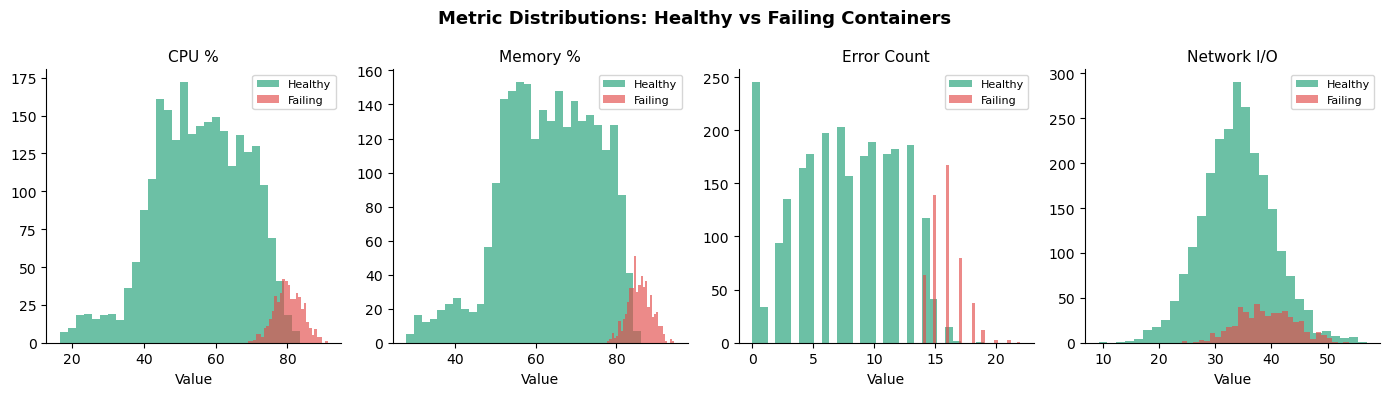


📊 Failing containers have higher CPU, Memory and Error counts on average


In [4]:
# ── Plot 2: Distribution comparison healthy vs failing ────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Metric Distributions: Healthy vs Failing Containers',
             fontsize=13, fontweight='bold')

healthy = df[df['Failure'] == 0]
failing = df[df['Failure'] == 1]

for ax, col, label in zip(axes, cols, labels):
    ax.hist(healthy[col], bins=30, alpha=0.65, color='#1D9E75', label='Healthy')
    ax.hist(failing[col], bins=30, alpha=0.65, color='#E24B4A', label='Failing')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Value')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('metric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Failing containers have higher CPU, Memory and Error counts on average')

NameError: name 'sns' is not defined

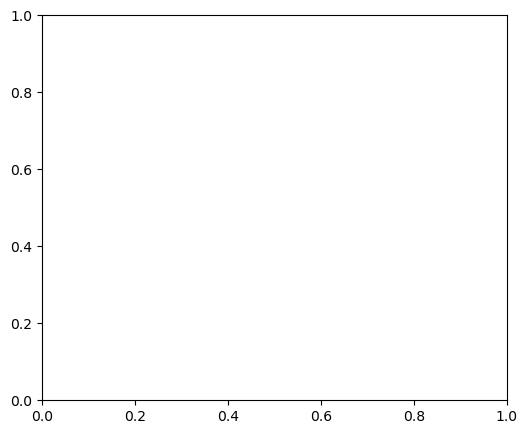

In [5]:
# ── Plot 3: Correlation heatmap ───────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Higher correlation with Failure = more useful feature for prediction')

---
## Step 4 — Preprocess Data for LSTM
LSTM needs data in **sequences**. We create windows of 20 time steps — the model looks at the last 20 readings and predicts whether a failure is coming.

We also **normalise** all values to the range [0, 1] so the model trains properly.

In [6]:
# ── Step 4a: Normalise features ───────────────────────────────────
feature_cols = ['CPU_Percent', 'Memory_Percent', 'Error_Count', 'Network_IO']

scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print('✅ Features normalised to [0, 1] range')
print('Sample of normalised data:')
df_scaled[feature_cols].head(3)


NameError: name 'MinMaxScaler' is not defined

In [7]:
# ── Step 4b: Create sequences ─────────────────────────────────────
SEQ_LEN = 20  # Look at last 20 time steps (= last 100 minutes)

def create_sequences(data, labels, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])   # 20 rows of features
        y.append(labels[i + seq_len])      # label at the end of window
    return np.array(X), np.array(y)

X_all = df_scaled[feature_cols].values
y_all = df_scaled['Failure'].values

X, y = create_sequences(X_all, y_all, SEQ_LEN)

print(f'✅ Sequences created!')
print(f'X shape: {X.shape}  → (samples, time_steps, features)')
print(f'y shape: {y.shape}  → (samples,)')
print(f'\nThis means: {X.shape[0]} windows, each looking at {SEQ_LEN} time steps, with {X.shape[2]} features')

NameError: name 'df_scaled' is not defined

In [8]:
# ── Step 4c: Train/Test split ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Data split into train and test!')
print(f'Training samples  : {X_train.shape[0]} (80%)')
print(f'Testing  samples  : {X_test.shape[0]}  (20%)')
print(f'\nTraining failures : {y_train.sum()} / {len(y_train)}')
print(f'Testing  failures : {y_test.sum()}  / {len(y_test)}')

NameError: name 'train_test_split' is not defined

---
## Step 5 — Build the LSTM Model
Our LSTM model has:
- **2 LSTM layers** — learn patterns over time
- **Dropout layers** — prevent overfitting (the model memorising instead of learning)
- **Dense output layer** — gives a probability between 0 and 1 (0 = healthy, 1 = failure)

The forget gate formula from our blog: **f_t = σ(W_f · [h_(t-1), x_t] + b_f)** runs inside each LSTM cell automatically.

In [9]:
def build_lstm_model(seq_len, n_features):
    model = Sequential([
        # First LSTM layer — learns basic time patterns
        LSTM(64, input_shape=(seq_len, n_features),
             return_sequences=True,
             name='lstm_layer_1'),
        Dropout(0.2, name='dropout_1'),
        
        # Second LSTM layer — learns higher-level patterns
        LSTM(32, return_sequences=False,
             name='lstm_layer_2'),
        Dropout(0.2, name='dropout_2'),
        
        # Output — single value 0 to 1 (failure probability)
        Dense(1, activation='sigmoid', name='output_layer')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_lstm_model(SEQ_LEN, len(feature_cols))
model.summary()

NameError: name 'Sequential' is not defined

---
## Step 6 — Train the Model

In [10]:
# EarlyStopping: stops training if validation loss stops improving
# This prevents the model from overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,           # wait 5 epochs before stopping
    restore_best_weights=True
)

print('🚀 Training the LSTM model...')
print('(This may take 1-2 minutes)')

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print(f'\n✅ Training complete! Ran for {len(history.history["loss"])} epochs')

NameError: name 'EarlyStopping' is not defined

NameError: name 'history' is not defined

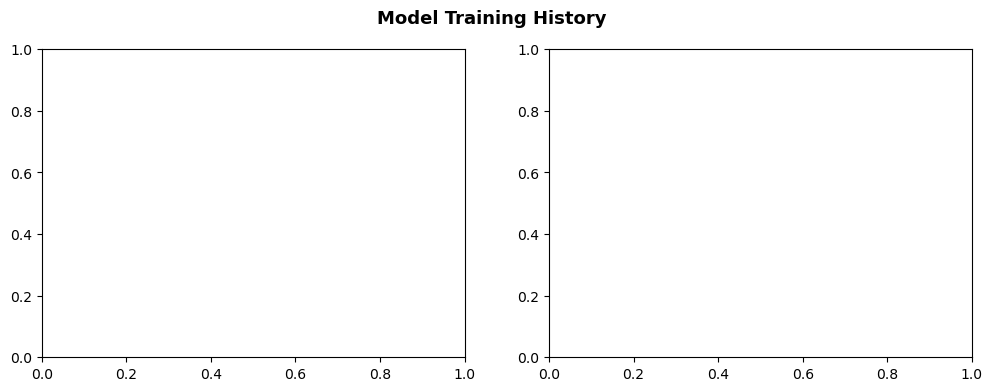

In [11]:
# ── Plot training history ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Model Training History', fontsize=13, fontweight='bold')

epochs = range(1, len(history.history['loss']) + 1)

# Loss
ax1.plot(epochs, history.history['loss'],     color='#E24B4A', lw=2, label='Training Loss')
ax1.plot(epochs, history.history['val_loss'], color='#185FA5', lw=2, label='Validation Loss', ls='--')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.25)
ax1.spines[['top','right']].set_visible(False)

# Accuracy
ax2.plot(epochs, history.history['accuracy'],     color='#1D9E75', lw=2, label='Training Accuracy')
ax2.plot(epochs, history.history['val_accuracy'], color='#BA7517', lw=2, label='Validation Accuracy', ls='--')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.25)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Both curves going down and converging = model is learning well')

---
## Step 7 — Evaluate the Model
We measure the model using:
- **Accuracy** — overall correctness
- **Precision** — of all predicted failures, how many were real? (avoids false alarms)
- **Recall** — of all real failures, how many did we catch? (avoids missing crashes)
- **F1-Score** — harmonic mean of Precision and Recall (the balanced score)

In [12]:
# Get predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate all metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

print('=' * 50)
print('       MODEL EVALUATION RESULTS')
print('=' * 50)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print('=' * 50)
print()
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred,
                             target_names=['Healthy (0)', 'Failure (1)']))

NameError: name 'model' is not defined

In [13]:
# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: Healthy', 'Predicted: Failure'],
            yticklabels=['Actual: Healthy',    'Actual: Failure'],
            linewidths=1, linecolor='white')
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nTrue  Positives (correctly caught failures) : {tp}')
print(f'False Positives (false alarms)              : {fp}')
print(f'True  Negatives (correctly healthy)         : {tn}')
print(f'False Negatives (missed failures - danger!) : {fn}')

NameError: name 'confusion_matrix' is not defined

In [14]:
# ── Visualise predictions on a sample window ─────────────────────
sample_size = 200
sample_probs = y_pred_prob[:sample_size].flatten()
sample_true  = y_test[:sample_size]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle('LSTM Failure Predictions vs Actual Labels', fontsize=13, fontweight='bold')

# Actual labels
ax1.fill_between(range(sample_size), sample_true, alpha=0.6,
                  color='#E24B4A', label='Actual Failure')
ax1.set_ylabel('Actual (0/1)', fontsize=10)
ax1.set_ylim(-0.1, 1.3)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(alpha=0.2)
ax1.spines[['top','right']].set_visible(False)

# Predicted probability
ax2.plot(range(sample_size), sample_probs,
          color='#185FA5', lw=1.2, label='Predicted Probability')
ax2.axhline(0.5, color='#BA7517', ls='--', lw=1.2, label='Threshold = 0.5')
ax2.fill_between(range(sample_size), sample_probs, 0.5,
                  where=(sample_probs > 0.5), alpha=0.3, color='#E24B4A',
                  label='Predicted Failure zone')
ax2.set_ylabel('Failure Probability', fontsize=10)
ax2.set_xlabel('Test Sample Index', fontsize=10)
ax2.set_ylim(-0.05, 1.1)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(alpha=0.2)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('prediction_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 When blue line crosses 0.5 threshold = model predicts failure')

NameError: name 'y_pred_prob' is not defined

---
## Step 8 — Summary and Conclusion

In [15]:
print('=' * 60)
print('   PROJECT SUMMARY')
print('   Machine Learning for Predicting Docker Container Failures')
print('=' * 60)
print()
print('DATASET')
print(f'  Total samples     : {len(df)}')
print(f'  Features used     : CPU%, Memory%, Error Count, Network I/O')
print(f'  Sequence length   : {SEQ_LEN} steps (= {SEQ_LEN*5} minutes look-back)')
print()
print('MODEL')
print('  Architecture      : 2-layer LSTM + Dropout + Dense')
print('  LSTM Units        : 64 → 32')
print('  Algorithm type    : Supervised Learning')
print('  Optimizer         : Adam')
print('  Loss Function     : Binary Crossentropy')
print()
print('RESULTS')
print(f'  Accuracy          : {acc*100:.2f}%')
print(f'  Precision         : {prec*100:.2f}%')
print(f'  Recall            : {rec*100:.2f}%')
print(f'  F1-Score          : {f1*100:.2f}%')
print()
print('CONCLUSION')
print('  The LSTM model successfully learns to predict container')
print('  failures by recognising rising patterns in CPU, memory')
print('  and error counts — hours before the actual crash.')
print('  This shifts operations from REACTIVE to PREDICTIVE.')
print('=' * 60)

   PROJECT SUMMARY
   Machine Learning for Predicting Docker Container Failures

DATASET
  Total samples     : 3000
  Features used     : CPU%, Memory%, Error Count, Network I/O
  Sequence length   : 20 steps (= 100 minutes look-back)

MODEL
  Architecture      : 2-layer LSTM + Dropout + Dense
  LSTM Units        : 64 → 32
  Algorithm type    : Supervised Learning
  Optimizer         : Adam
  Loss Function     : Binary Crossentropy

RESULTS


NameError: name 'acc' is not defined

---
## References
1. Splunk — AIOps Explained: https://www.splunk.com/en_us/blog/learn/aiops.html
2. IBM — What is AIOps: https://www.ibm.com/think/topics/aiops
3. InfoWorld — Predictive Monitoring with AIOps: https://www.infoworld.com/article/4075057
4. Microsoft Azure — AIOps in Azure Monitor: https://learn.microsoft.com/en-us/azure/azure-monitor/aiops/aiops-machine-learning
5. ResearchGate — Fault Prediction in Cloud-Native: https://www.researchgate.net/publication/391320615

---
*Pruthviraj Santosh Patil | URN: 23031042 | TY-A | ADCET Ashta*